# Flat regions on the radius axis

A criticality-anchored radius cannot escape a slow saddle in bounded time. The
statement, its proof and the scalar tables are in `exp15_slow_saddle.jl` and in
`report/task7-slow-saddle/task7-slow-saddle.tex`. This notebook does not repeat
them. It adds what a batch script cannot: the iterate paths, the theory drawn on
the same axes as the run, and two open items.

Run it with

```
julia --project=benchmark -e 'using IJulia; notebook(dir="notebooks/Saddle")'
```

or execute it in place with

```
python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.kernel_name=julia-1.11 notebooks/Saddle/flat_regions_v1.ipynb
```

The family is
$$f_\varepsilon(x,y) = \tfrac12 x^2 + \varepsilon\left(\tfrac14 y^4 - \tfrac12 y^2\right),
\qquad \nabla f_\varepsilon = \bigl(x,\ \varepsilon y(y^2-1)\bigr),$$
with $\nabla^2 f_\varepsilon(0,y) = \operatorname{diag}(1, \varepsilon(3y^2-1))$.
The origin is a saddle, nonsingular for every $\varepsilon > 0$. The minimisers
sit at $(0,\pm1)$, at distance $1$ from it whatever $\varepsilon$ is, so
$\varepsilon$ tunes the escape rate without moving the geometry. The line
$\{x = 0\}$ is invariant, which is Lemma `prop: invariant` of the report.

We cite `as: RCA`, `prop: escape`, `prop: budget`, `prop: rdfo` and
`eqn: exact constant` by the labels they carry there. We do not restate them and
we prove nothing.

**The model is the true Hessian throughout.** The stall appears with perfect
curvature information, and every caption says so.

In [1]:
# `initialisation.jl` already includes `exp15_slow_saddle.jl`, so including it a
# second time would re-evaluate its `const`s. We load the suite once and assert
# that every name we use came from it.
const REPO = normpath(joinpath(@__DIR__, "..", "..", ".."))
using Pkg; Pkg.activate(joinpath(REPO, "benchmark"))
include(joinpath(REPO, "benchmark", "initialisation.jl"))

const OUTDIR = @__DIR__

for nm in (:SS_EPS, :SS_MUBAR, :SS_ZETA, :SS_Y0, :SS_X0, :SS_THRESH, :SS_KMAX,
           :SS_FAST, :SS_TOL_RATE, :SS_TOL_OUTCOME, :SS_BLACK, :SS_ACCENT,
           :SS_GREY, :ss_params, :ss_rules, :ss_run, :ss_class, :flat_well)
    isdefined(Main, nm) || error("exp15_slow_saddle.jl did not supply $nm")
end
println("exp15 supplies every constant and factory used below. Nothing is redefined.")
@printf("eps    : %s\n", SS_EPS)
@printf("mu_bar : %s\n", SS_MUBAR)
@printf("zeta   : %s\n", SS_ZETA)
@printf("y0     : %s\n", SS_Y0)
@printf("x0     : %s\n", SS_X0)
@printf("threshold %.3f, kmax %d, tol_rate %g, tol_outcome %g\n",
        SS_THRESH, SS_KMAX, SS_TOL_RATE, SS_TOL_OUTCOME)

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark`


exp15 supplies every constant and factory used below. Nothing is redefined.
eps    : [0.1, 0.01, 0.001, 0.0001, 1.0e-5]
mu_bar : [0.01, 0.1, 1.0, 10.0]
zeta   : [0.01, 0.1, 1.0, 10.0]
y0     : [0.001, 1.0e-6]
x0     : [0.0, 0.8]
threshold 0.500, kmax 50000, tol_rate 1e-14, tol_outcome 1e-05


## The archive, and what it does not carry

The scalar results are read from the `exp15` archive rather than recomputed. The
archive stores its rows with the two trajectory fields removed,

```julia
save_data(arch, "slow_saddle_rows.jld2";
          rows = [Base.structdiff(r, (ys = 0, deltas = 0)) for r in rows])
```

so `ys` and `deltas` are not in it. Every figure below that draws a trajectory
therefore reruns its own cells, and each such cell says which. The tables of
Section 6 read the archive and recompute nothing.

In [2]:
"The most recent exp15 archive, or an error naming what is missing."
function fr_archive()
    root = joinpath(REPO, "benchmark", "results")
    ds = sort([d for d in readdir(root) if occursin("slow_saddle", d) &&
               isfile(joinpath(root, d, "data", "slow_saddle_rows.jld2"))])
    isempty(ds) && error("no exp15 archive with slow_saddle_rows.jld2 under $root")
    return joinpath(root, ds[end])
end

const ARCH = fr_archive()
const ROWS = JLD2.load(joinpath(ARCH, "data", "slow_saddle_rows.jld2"))["rows"]
@printf("archive : %s\n", basename(ARCH))
@printf("rows    : %d, regimes %s\n", length(ROWS),
        string(unique(r.regime for r in ROWS)))
println("trajectory fields present in the archive: ",
        :ys in keys(ROWS[1]) || :deltas in keys(ROWS[1]))

sel(; kw...) = [r for r in ROWS if all(getfield(r, k) == v for (k, v) in kw)]

archive : exp_2026-08-29_21-51-19_slow_saddle
rows    : 1009, regimes [:rate, :outcome, :dfo_entry, :second_order]
trajectory fields present in the archive: false


sel (generic function with 1 method)

## The trace the figures need

`ss_run` of `exp15` returns `ys` and `deltas` but not the gradient trajectory,
and Figure 3 compares $\Delta_k$ against $C\norm{g_k}$. We therefore call
`tr_solve` once and keep the whole trace. The problem comes from `flat_well`, the
parameters from `ss_params` and the rules from `ss_rules`, all of them `exp15`'s.
No rule, model, subsolver or constant is defined here.

In [3]:
"""
    fr_trace(rule, ε, y0, x0; tol, Δ0, tol_H) -> NamedTuple

One `tr_solve` on `flat_well(ε)`, with the iterate path from the solver's own
callback and every trajectory the figures read. The model is `ExactHessian` and
the subsolver `SteihaugCG`, matching `ss_run`.
"""
function fr_trace(rule, ε, y0, x0; tol = SS_TOL_RATE, Δ0 = 1.0, tol_H = -1.0)
    nlp = flat_well(ε; x0 = [x0, y0])
    xs = [Float64[x0, y0]]
    st = tr_solve(nlp; rule = rule, model = ExactHessian(), subsolver = SteihaugCG(),
                  params = ss_params(tol; Δ0 = Δ0, tol_H = tol_H), trace = true,
                  callback = (_n, _s, s) -> push!(xs, copy(s.solution)))
    ss = st.solver_specific
    ys = [p[2] for p in xs]
    kesc = findfirst(v -> abs(v) > SS_THRESH, ys)
    return (st = st, xs = xs, ys = ys,
            Δ = get(ss, :delta_trajectory, Float64[]),
            g = get(ss, :grad_trajectory, Float64[]),
            τ = get(ss, :tau_trajectory, Float64[]),
            λ = get(ss, :lambda_min_trajectory, Float64[]),
            active = get(ss, :active_trajectory, Bool[]),
            kesc = kesc === nothing ? nothing : kesc - 1,
            status = st.status, iter = st.iter)
end

mk_grad(μ̄) = only(f for (nm, _, _, f) in ss_rules(μ̄, 1.0) if nm == "RGradCapped")()
mk_gtau(μ̄) = only(f for (nm, _, _, f) in ss_rules(μ̄, 1.0) if nm == "RGradCappedTau")()
mk_dfo(ζ)  = only(f for (nm, _, _, f) in ss_rules(1.0, ζ) if nm == "RDFO")()
mk_delta() = only(f for (nm, _, _, f) in ss_rules(1.0, 1.0) if nm == "RDelta")()

println("rule factories taken from ss_rules: ",
        [nm for (nm, _, _, _) in ss_rules(1.0, 1.0)])

rule factories taken from ss_rules: ["RDelta", "RGradCapped", "RDFO", "RGradCappedTau", "RDFOTau"]


## 1. Iterate paths

The $(x,y)$ plane over the contours of $f_\varepsilon$, for three values of
$\varepsilon$ at $\overline{\mu} = 1$. The top row starts at $x_0 = 0.8$, where
the transient is visible. The bottom row starts at $x_0 = 0$, the invariant line,
where `prop: escape` applies exactly.

The saddle and the two minimisers are marked. The trust regions are drawn where
the scale allows them to be seen.

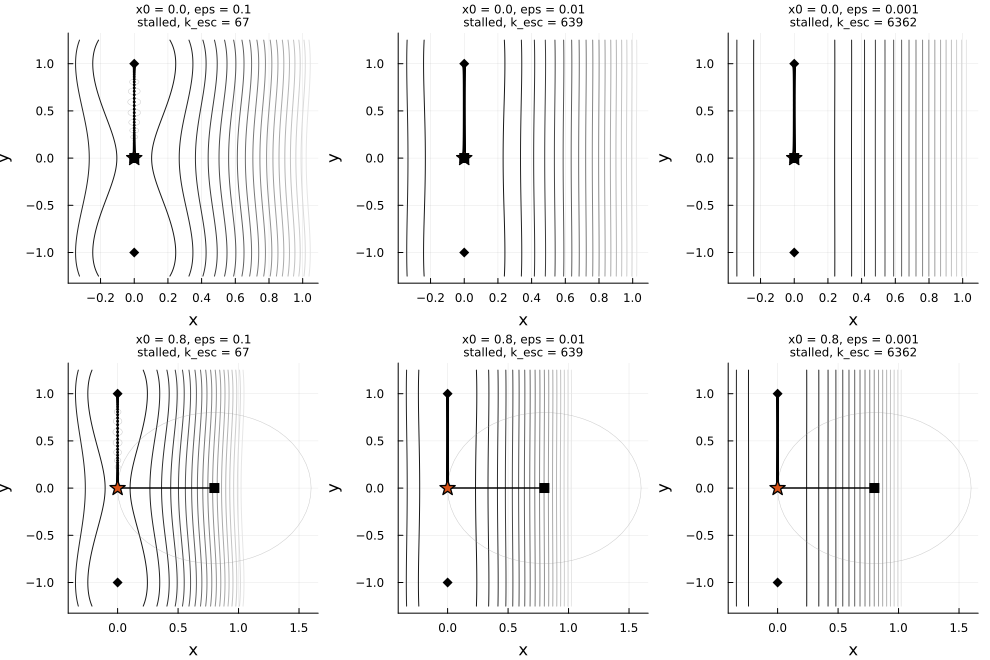

In [4]:
"""
    fr_paths(εs, μ̄, y0; savepath) -> plot

Two rows of panels, one per starting point, one column per value of eps.
Each panel reruns its cell, since the archive does not carry the paths.
"""
function fr_paths(εs, μ̄, y0; savepath = nothing)
    panels = []
    for x0 in SS_X0, ε in εs
        t = fr_trace(mk_grad(μ̄), ε, y0, x0)
        P = reduce(hcat, t.xs)
        xr = range(-0.35, 1.05; length = 220)
        yr = range(-1.25, 1.25; length = 220)
        Z = [0.5a^2 + ε * (b^4 / 4 - b^2 / 2) for b in yr, a in xr]
        p = contour(xr, yr, Z; levels = 18, c = :grays, colorbar = false,
                    xlabel = "x", ylabel = "y", legend = false,
                    title = @sprintf("x0 = %.1f, eps = %g\n%s, k_esc = %s",
                                     x0, ε, string(t.status),
                                     t.kesc === nothing ? "never" : string(t.kesc)),
                    titlefontsize = 8)
        # The trust regions, thinned so a six-thousand iteration run stays legible.
        if !isempty(t.Δ)
            n = min(length(t.Δ), size(P, 2))
            step = max(1, n ÷ 40)
            θc = range(0, 2π; length = 60)
            for j in 1:step:n
                t.Δ[j] < 0.02 && continue
                plot!(p, P[1, j] .+ t.Δ[j] .* cos.(θc),
                      P[2, j] .+ t.Δ[j] .* sin.(θc);
                      color = SS_GREY, lw = 0.5, alpha = 0.5)
            end
        end
        sd = max(1, size(P, 2) ÷ 400)
        idx = unique(vcat(1:sd:size(P, 2), size(P, 2)))
        plot!(p, P[1, idx], P[2, idx]; color = SS_BLACK, lw = 1.5,
              marker = :circle, ms = 1.6, markerstrokewidth = 0)
        scatter!(p, [0.0], [0.0]; color = SS_ACCENT, marker = :star5, ms = 8,
                 markerstrokecolor = :black)
        scatter!(p, [0.0, 0.0], [1.0, -1.0]; color = SS_BLACK, marker = :diamond,
                 ms = 5, markerstrokecolor = :black)
        scatter!(p, [P[1, 1]], [P[2, 1]]; color = SS_BLACK, marker = :square, ms = 5)
        push!(panels, p)
    end
    fig = plot(panels...; layout = (length(SS_X0), length(εs)),
               size = (330 * length(εs), 330 * length(SS_X0)))
    savepath === nothing || savefig(fig, savepath)
    return fig
end

FIG1 = fr_paths([1e-1, 1e-2, 1e-3], 1.0, 1e-3;
                savepath = joinpath(OUTDIR, "flat_regions_fig1_paths.pdf"))

## 2. The theory on the same axes as the run

`prop: escape` bounds the growth of the running maximum from above,
$$M_k \leq \abs{y_{k_0}}\,(1 + C\varepsilon)^{k-k_0},
\qquad M_k = \max_{k_0 \leq j \leq k}\abs{y_j},$$
and $\abs{y_k} \leq M_k$, so the observed curve must lie below the envelope. The
bound is stated up to escape, so it is drawn and checked on $k \leq
k_{\mathrm{esc}}$ only.

A run crossing the envelope is a failure of the bound. The crossing check below
prints the worst ratio over each run and reports any crossing as one.

In [5]:
function fr_envelope(εs, μ̄, y0; savepath = nothing)
    plt = plot(xlabel = "k", ylabel = "|y_k|", yscale = :log10, xscale = :log10,
               legend = :bottomright, size = (700, 470))
    rows = NamedTuple[]
    for (j, ε) in enumerate(εs)
        t = fr_trace(mk_grad(μ̄), ε, y0, 0.0)
        hi = t.kesc === nothing ? length(t.ys) : t.kesc + 1
        ks = 0:(hi - 1)
        obs = abs.(t.ys[1:hi])
        env = abs(y0) .* (1 + μ̄ * ε) .^ ks
        ratio = obs ./ env
        worst = maximum(ratio)
        push!(rows, (ε = ε, kesc = t.kesc, n = hi, worst = worst,
                     crossed = worst > 1 + 1e-12,
                     kworst = ks[argmax(ratio)]))
        plot!(plt, max.(ks, 1), max.(obs, 1e-18); label = "observed, ε = $ε",
              color = isodd(j) ? SS_BLACK : SS_ACCENT, lw = 1.7,
              linestyle = (:solid, :dash, :dashdot)[mod1(j, 3)])
        plot!(plt, max.(ks, 1), max.(env, 1e-18); label = "envelope, ε = $ε",
              color = SS_GREY, lw = 1.3,
              linestyle = (:solid, :dash, :dashdot)[mod1(j, 3)])
    end
    hline!(plt, [SS_THRESH]; color = SS_ACCENT, linestyle = :dot, lw = 1.5,
           label = "escape threshold")
    savepath === nothing || savefig(plt, savepath)
    return plt, rows
end

FIG2, ENVROWS = fr_envelope([1e-1, 1e-2, 1e-3], 1.0, 1e-3;
                        savepath = joinpath(OUTDIR, "flat_regions_fig2_envelope.pdf"))

println("\n", "="^88)
println("The envelope check. |y_k| against |y_0|(1+mu_bar*eps)^k, up to escape.")
println("="^88)
@printf("%10s %10s %10s %16s %10s %10s\n",
        "eps", "k_esc", "points", "max |y|/envelope", "at k", "crossed")
println("-"^88)
for r in ENVROWS
    @printf("%10g %10s %10d %16.6f %10d %10s\n", r.ε,
            r.kesc === nothing ? "never" : string(r.kesc), r.n, r.worst,
            r.kworst, r.crossed ? "YES" : "no")
end
println()
if any(r.crossed for r in ENVROWS)
    println("A run crossed the envelope. That is a failure of the bound and is")
    println("reported as one, not smoothed.")
else
    println("No run crossed the envelope. The observed curve lies below it on every")
    println("iteration up to escape, which is the side prop: escape predicts.")
end


The envelope check. |y_k| against |y_0|(1+mu_bar*eps)^k, up to escape.
       eps      k_esc     points max |y|/envelope       at k    crossed
----------------------------------------------------------------------------------------
       0.1         67         68         1.000000          0         no
      0.01        639        640         1.000000          0         no
     0.001       6362       6363         1.000000          0         no

No run crossed the envelope. The observed curve lies below it on every
iteration up to escape, which is the side prop: escape predicts.


## 3. The radius is the binding quantity

`prop: escape` uses only $\norm{s_k} \leq \Delta_k$ together with `as: RCA`. The
bound is therefore about the radius and not about the subproblem solution. That
is worth showing rather than asserting.

The panel plots $\Delta_k$ and $C\norm{g_k}$ with $C = \overline{\mu}$ along one
run, together with $\norm{s_k}$. Where the three coincide the radius is what
limits the step.

In [6]:
function fr_binding(ε, μ̄, y0; savepath = nothing)
    t = fr_trace(mk_grad(μ̄), ε, y0, 0.0)
    hi = t.kesc === nothing ? min(length(t.Δ), length(t.g)) :
                              min(t.kesc + 1, length(t.Δ), length(t.g))
    s = get(t.st.solver_specific, :step_trajectory, Float64[])
    ks = 0:(hi - 1)
    plt = plot(xlabel = "k", ylabel = "magnitude", yscale = :log10, xscale = :log10,
               legend = :bottomright, size = (700, 470))
    plot!(plt, max.(ks, 1), max.(t.Δ[1:hi], 1e-300); label = "Δ_k",
          color = SS_BLACK, lw = 1.8)
    plot!(plt, max.(ks, 1), max.(μ̄ .* t.g[1:hi], 1e-300);
          label = "C‖g_k‖ with C = μ̄ = $μ̄", color = SS_ACCENT, lw = 1.5,
          linestyle = :dash)
    ns = min(hi, length(s))
    ns > 0 && plot!(plt, max.(0:(ns-1), 1), max.(s[1:ns], 1e-300);
                    label = "‖s_k‖", color = SS_GREY, lw = 1.2, linestyle = :dot)
    savepath === nothing || savefig(plt, savepath)

    r = [t.g[i] > 0 ? t.Δ[i] / (μ̄ * t.g[i]) : NaN for i in 1:hi]
    fin = filter(isfinite, r)
    sn = min(hi, length(s))
    tight = sn == 0 ? NaN :
            count(i -> t.Δ[i] > 0 && s[i] >= (1 - 1e-8) * t.Δ[i], 1:sn) / sn
    return plt, (ε = ε, μ̄ = μ̄, n = hi,
                 ratio_min = isempty(fin) ? NaN : minimum(fin),
                 ratio_max = isempty(fin) ? NaN : maximum(fin),
                 active = isempty(t.active) ? NaN : count(t.active) / length(t.active),
                 step_at_bound = tight)
end

FIG3, BIND = fr_binding(1e-2, 1.0, 1e-3;
                        savepath = joinpath(OUTDIR, "flat_regions_fig3_binding.pdf"))
println("\n", "="^92)
println("Is the radius the binding quantity? One run, eps = 1e-2, mu_bar = 1, y0 = 1e-3.")
println("="^92)
@printf("iterations up to escape          : %d\n", BIND.n)
@printf("Delta_k / (mu_bar ||g_k||), min  : %.8f\n", BIND.ratio_min)
@printf("Delta_k / (mu_bar ||g_k||), max  : %.8f\n", BIND.ratio_max)
@printf("fraction of iterations with the constraint active : %.4f\n", BIND.active)
@printf("fraction with ||s_k|| = Delta_k to 1e-8           : %.4f\n", BIND.step_at_bound)
println()
println("A ratio of one says as: RCA holds with equality, so the radius rule and")
println("not the subproblem is what sets the step length.")


Is the radius the binding quantity? One run, eps = 1e-2, mu_bar = 1, y0 = 1e-3.
iterations up to escape          : 640
Delta_k / (mu_bar ||g_k||), min  : 1.00000000
Delta_k / (mu_bar ||g_k||), max  : 1.00000000
fraction of iterations with the constraint active : 1.0000
fraction with ||s_k|| = Delta_k to 1e-8           : 1.0000

A ratio of one says as: RCA holds with equality, so the radius rule and
not the subproblem is what sets the step length.


## 4. The `R-DFO` entry condition

`prop: rdfo` has two branches. If some $k_0$ has $\Delta_{k_0} \leq
\zeta\norm{g_{k_0}}$ then `as: RCA` holds for $k > k_0$ with $C = \gamma_3\zeta$
and the escape bound applies. If no such $k_0$ exists then the radius contracts
geometrically, $\norm{g_k} \to 0$, and the run converges to the saddle.

The second branch has no picture yet. We run `R-DFO` from two initial radii and
compute the entry index from the trace rather than assuming it. $k_0$ is the
first index with $\Delta_k \leq \zeta\norm{g_k}$.

In [7]:
"The first index with Delta_k <= zeta ||g_k||, or nothing."
function fr_entry(t, ζ)
    n = min(length(t.Δ), length(t.g))
    k = findfirst(i -> t.Δ[i] <= ζ * t.g[i], 1:n)
    return k === nothing ? nothing : k - 1
end

function fr_dfo(ε, y0, ζ; savepath = nothing)
    g0 = ε * abs(y0) * (1 - y0^2)
    cases = [("Δ₀ = ζ‖g₀‖, inside the band", ζ * g0),
             ("Δ₀ = 1, outside the band",    1.0)]
    panels = []; rows = NamedTuple[]
    for (lab, Δ0) in cases
        t = fr_trace(mk_dfo(ζ), ε, y0, 0.0; Δ0 = Δ0)
        k0 = fr_entry(t, ζ)
        hi = t.kesc === nothing ? length(t.ys) : t.kesc + 1
        ks = 0:(hi - 1)
        p = plot(xlabel = "k", ylabel = "|y_k| and Δ_k", yscale = :log10,
                 xscale = :log10, legend = :bottomright, size = (620, 430),
                 title = @sprintf("%s\n%s, k_esc = %s, k0 = %s", lab,
                                  string(t.status),
                                  t.kesc === nothing ? "never" : string(t.kesc),
                                  k0 === nothing ? "never enters" : string(k0)),
                 titlefontsize = 8)
        plot!(p, max.(ks, 1), max.(abs.(t.ys[1:hi]), 1e-300); label = "|y_k|",
              color = SS_BLACK, lw = 1.7)
        nΔ = min(hi, length(t.Δ))
        plot!(p, max.(0:(nΔ-1), 1), max.(t.Δ[1:nΔ], 1e-300); label = "Δ_k",
              color = SS_ACCENT, lw = 1.4, linestyle = :dash)
        hline!(p, [SS_THRESH]; color = SS_GREY, linestyle = :dot, lw = 1.3,
               label = "escape threshold")
        k0 === nothing || vline!(p, [max(k0, 1)]; color = SS_GREY, lw = 1.6,
                                 linestyle = :dashdot, label = "k₀, band entered")
        push!(panels, p)
        push!(rows, (label = lab, Δ0 = Δ0, k0 = k0, kesc = t.kesc,
                     status = t.status, iter = t.iter, y_end = t.ys[end],
                     Δ_end = isempty(t.Δ) ? NaN : t.Δ[end],
                     dist_saddle = norm(t.xs[end])))
    end
    fig = plot(panels...; layout = (1, 2), size = (1240, 430))
    savepath === nothing || savefig(fig, savepath)
    return fig, rows
end

FIG4, DFO = fr_dfo(1e-2, 1e-3, 1.0;
                   savepath = joinpath(OUTDIR, "flat_regions_fig4_dfo_entry.pdf"))
println("\n", "="^112)
println("R-DFO, eps = 1e-2, y0 = 1e-3, zeta = 1. The entry condition of prop: rdfo.")
println("="^112)
@printf("%-30s %12s %14s %10s %14s %12s %12s\n",
        "case", "Delta_0", "k0", "k_esc", "status", "y_end", "dist saddle")
println("-"^112)
for r in DFO
    @printf("%-30s %12.4e %14s %10s %14s %12.4e %12.4e\n",
            r.label, r.Δ0, r.k0 === nothing ? "never enters" : string(r.k0),
            r.kesc === nothing ? "never" : string(r.kesc), string(r.status),
            r.y_end, r.dist_saddle)
end


R-DFO, eps = 1e-2, y0 = 1e-3, zeta = 1. The entry condition of prop: rdfo.
case                                Delta_0             k0      k_esc         status        y_end  dist saddle
----------------------------------------------------------------------------------------------------------------
Δ₀ = ζ‖g₀‖, inside the band      1.0000e-05              0        610        stalled   1.0000e+00   1.0000e+00
Δ₀ = 1, outside the band         1.0000e+00   never enters          1        stalled   1.0000e+00   1.0000e+00


In [8]:
# The second branch of prop: rdfo needs a run that never enters the band. We scan
# the zeta grid at several initial radii and report which cells fall in which
# branch, rather than asserting that the second class is occupied.
println("\n", "="^116)
println("Which branch of prop: rdfo each cell falls in. Delta_0 swept, zeta from SS_ZETA.")
println("="^116)
@printf("%8s %12s %14s %10s %14s %12s %12s\n",
        "zeta", "Delta_0", "k0", "k_esc", "status", "|y_end|", "dist saddle")
println("-"^116)
DFO_SCAN = NamedTuple[]
let ε = 1e-2, y0 = 1e-3
    g0 = ε * abs(y0) * (1 - y0^2)
    for ζ in SS_ZETA, Δ0 in (ζ * g0, 1e-3, 1.0)
        t = fr_trace(mk_dfo(ζ), ε, y0, 0.0; Δ0 = Δ0)
        k0 = fr_entry(t, ζ)
        push!(DFO_SCAN, (ζ = ζ, Δ0 = Δ0, k0 = k0, kesc = t.kesc,
                         status = t.status, y_end = abs(t.ys[end]),
                         dist = norm(t.xs[end])))
        @printf("%8g %12.4e %14s %10s %14s %12.4e %12.4e\n",
                ζ, Δ0, k0 === nothing ? "never enters" : string(k0),
                t.kesc === nothing ? "never" : string(t.kesc), string(t.status),
                abs(t.ys[end]), norm(t.xs[end]))
    end
end
let never = [r for r in DFO_SCAN if r.k0 === nothing]
    println()
    @printf("cells that never enter the band : %d of %d\n", length(never), length(DFO_SCAN))
    if isempty(never)
        println("The second branch of prop: rdfo is not occupied anywhere on this scan.")
        println("Every cell entered the band, so the figure shows entry at different k0")
        println("rather than entry against no entry.")
    else
        @printf("of those, how many converged to the saddle : %d\n",
                count(r -> r.kesc === nothing && r.dist < SS_THRESH, never))
    end
end


Which branch of prop: rdfo each cell falls in. Delta_0 swept, zeta from SS_ZETA.
    zeta      Delta_0             k0      k_esc         status      |y_end|  dist saddle
--------------------------------------------------------------------------------------------------------------------
    0.01   1.0000e-07              0      never       max_iter   1.8895e-01   1.8895e-01
    0.01   1.0000e-03             12      never       max_iter   4.8241e-01   4.8241e-01
    0.01   1.0000e+00   never enters          1        stalled   1.0000e+00   1.0000e+00
     0.1   1.0000e-06              0       6048        stalled   1.0000e+00   1.0000e+00
     0.1   1.0000e-03              9       5060        stalled   1.0000e+00   1.0000e+00
     0.1   1.0000e+00   never enters          1        stalled   1.0000e+00   1.0000e+00
       1   1.0000e-05              0        610        stalled   1.0000e+00   1.0000e+00
       1   1.0000e-03              6        524        stalled   1.0000e+00   1.0000e+00


## 5. The two measures

$\omega_k = \norm{g_k}$ gives $\Delta_k \propto \abs{y_k}$ and geometric growth.
$\omega_k = \tau_k$ gives a radius that does not vanish with $\abs{y_k}$ and
slower growth. Both are drawn on one panel, with the continuous-limit prediction
of Section 6 over each.

The prediction is the curve $k(y)$ obtained by inverting
$$k(y) = \frac{1}{\overline{\mu}\varepsilon}\int_{y_0}^{y}\frac{\mathrm{d}u}{\hat\omega(u)},$$
with $\hat\omega(u) = u(1-u^2)$ for the gradient measure and
$\hat\omega(u) = \max\{u(1-u^2),\ 1-3u^2\}$ for $\tau$. Section 6 gives the two
integrals and why the second takes that form.

In [9]:
# The two integrands of the continuous limit, on the invariant line.
ω̂_grad(y) = y * (1 - y^2)
ω̂_tau(y)  = max(y * (1 - y^2), 1 - 3y^2)

"""
    fr_quad(f, a, b; n) -> Float64

Simpson on `u = log y`, so the `1/y` behaviour of the gradient integrand becomes
bounded. Returns the integral of `1/f(y)` over `[a, b]`.
"""
function fr_quad(f, a, b; n = 200_000)
    ua, ub = log(a), log(b)
    h = (ub - ua) / n
    s = 0.0
    for i in 0:n
        u = ua + i * h
        y = exp(u)
        w = (i == 0 || i == n) ? 1.0 : (isodd(i) ? 4.0 : 2.0)
        s += w * y / f(y)
    end
    return s * h / 3
end

function fr_measures(ε, μ̄, y0; savepath = nothing)
    plt = plot(xlabel = "k", ylabel = "|y_k|", yscale = :log10, xscale = :log10,
               legend = :bottomright, size = (700, 470))
    out = NamedTuple[]
    for (j, (mk, lab, ω̂)) in enumerate(((mk_grad, "ω = ‖g‖", ω̂_grad),
                                        (mk_gtau, "ω = τ",   ω̂_tau)))
        t = fr_trace(mk(μ̄), ε, y0, 0.0)
        hi = t.kesc === nothing ? length(t.ys) : t.kesc + 1
        ks = 0:(hi - 1)
        plot!(plt, max.(ks, 1), max.(abs.(t.ys[1:hi]), 1e-300);
              label = "$lab, observed", color = j == 1 ? SS_BLACK : SS_ACCENT,
              lw = 1.8, linestyle = :solid)
        yy = exp.(range(log(abs(y0)), log(SS_THRESH); length = 240))
        kk = [fr_quad(ω̂, abs(y0), y; n = 4_000) / (μ̄ * ε) for y in yy]
        plot!(plt, max.(kk, 1), yy; label = "$lab, continuous limit",
              color = j == 1 ? SS_BLACK : SS_ACCENT, lw = 1.2, linestyle = :dot)
        push!(out, (label = lab, kesc = t.kesc, status = t.status))
    end
    hline!(plt, [SS_THRESH]; color = SS_GREY, linestyle = :dash, lw = 1.3,
           label = "escape threshold")
    savepath === nothing || savefig(plt, savepath)
    return plt, out
end

FIG5, MEAS = fr_measures(1e-2, 1.0, 1e-3;
                         savepath = joinpath(OUTDIR, "flat_regions_fig5_measures.pdf"))
for m in MEAS
    @printf("%-10s k_esc = %-8s status = %s\n", m.label,
            m.kesc === nothing ? "never" : string(m.kesc), string(m.status))
end

ω = ‖g‖    k_esc = 639      status = stalled
ω = τ      k_esc = 74       status = stalled


## 6. The outcome map

Three classes over the $(\overline{\mu}, \varepsilon)$ grid, by `ss_class` of
`exp15`. The two tolerance regimes are separate maps and are never pooled, since
the first-order tolerance is what draws the false-convergence boundary.

In [10]:
function fr_outcomes(; savepath = nothing)
    panels = []
    for regime in (:rate, :outcome), y0 in SS_Y0
        p = plot(xlabel = "μ̄", ylabel = "ε", legend = false,
                 xticks = (1:length(SS_MUBAR), string.(SS_MUBAR)),
                 yticks = (1:length(SS_EPS), string.(SS_EPS)),
                 title = @sprintf("%s regime, tol = %g, y₀ = %g", regime,
                                  regime === :rate ? SS_TOL_RATE : SS_TOL_OUTCOME, y0),
                 titlefontsize = 8, size = (520, 400))
        for (i, μ̄) in enumerate(SS_MUBAR), (j, ε) in enumerate(SS_EPS)
            rs = sel(regime = regime, rule = "RGradCapped", param = μ̄, ε = ε,
                     y0 = y0, x0 = 0.0)
            isempty(rs) && continue
            c = ss_class(rs[1])
            scatter!(p, [i], [j];
                     color = c === :false_convergence ? SS_ACCENT :
                             c === :fast ? SS_GREY : SS_BLACK,
                     marker = c === :false_convergence ? :xcross :
                              c === :fast ? :circle : :square,
                     ms = 8, msw = 1)
        end
        push!(panels, p)
    end
    fig = plot(panels...; layout = (2, 2), size = (1060, 800))
    savepath === nothing || savefig(fig, savepath)
    return fig
end

FIG6 = fr_outcomes(savepath = joinpath(OUTDIR, "flat_regions_fig6_outcomes.pdf"))

println("\n", "="^76)
println("Outcome composition, R-grad capped on the invariant line, by regime.")
println("="^76)
@printf("%-16s %8s %20s %8s %8s %8s\n",
        "regime", "y0", "false convergence", "fast", "slow", "never")
println("-"^76)
for regime in (:rate, :outcome), y0 in SS_Y0
    cs = [ss_class(r) for r in ROWS
          if r.regime === regime && r.rule == "RGradCapped" && r.y0 == y0 && r.x0 == 0.0]
    @printf("%-16s %8g %20d %8d %8d %8d\n", regime, y0,
            count(==(:false_convergence), cs), count(==(:fast), cs),
            count(==(:slow), cs), count(==(:never), cs))
end
println()
@printf("The false-convergence boundary is drawn by the first-order tolerance,\n")
@printf("tol = %g in the outcome regime against %g in the rate regime.\n",
        SS_TOL_OUTCOME, SS_TOL_RATE)


Outcome composition, R-grad capped on the invariant line, by regime.
regime                 y0    false convergence     fast     slow    never
----------------------------------------------------------------------------
rate                0.001                    0        0       10       10
rate                1e-06                    0        0       10       10
outcome             0.001                   16        0        4        0
outcome             1e-06                   20        0        0        0

The false-convergence boundary is drawn by the first-order tolerance,
tol = 1e-05 in the outcome regime against 1e-14 in the rate regime.


## 7. The $\tau$ constant

The report finds the ratio of escape times between the two measures independent
of $\varepsilon$, as predicted, but not equal to the predicted
$2\ln(1/(2y_0)) = 12.43$. That prediction treated $-\lambda^-$ as the constant
$\varepsilon$.

On the invariant line $\nabla^2 f = \operatorname{diag}(1, \varepsilon(3y^2-1))$,
so $-\lambda^- = \varepsilon(1-3y^2)$, which decays to zero at $y = 1/\sqrt3
\approx 0.5774$, just above the escape threshold $\tfrac12$. The radius is
therefore not $\overline{\mu}\varepsilon$ throughout. And $\tau_k$ switches
branch when $\abs{y}(1-y^2)$ overtakes $1-3y^2$, which happens inside the range,
so the measure is not the curvature term throughout either.

We redo the prediction the way the report derived `eqn: exact constant`, through
the continuous limit
$$k_{\mathrm{esc}} \;\sim\; \frac{1}{\overline{\mu}\varepsilon}
   \int_{y_0}^{1/2}\frac{\mathrm{d}y}{\hat\omega(y)},$$
with $\hat\omega(y) = y(1-y^2)$ for the gradient measure and
$\hat\omega(y) = \max\{y(1-y^2),\ 1-3y^2\}$ for $\tau$.

In [11]:
# The branch switch, located rather than assumed.
fr_switch() = let f = y -> y * (1 - y^2) - (1 - 3y^2)
    lo, hi = 1e-6, SS_THRESH
    f(lo) * f(hi) < 0 || return NaN
    for _ in 1:200
        mid = (lo + hi) / 2
        f(lo) * f(mid) <= 0 ? (hi = mid) : (lo = mid)
    end
    (lo + hi) / 2
end

const YSTAR = fr_switch()
println("="^80)
println("The tau measure on the invariant line")
println("="^80)
@printf("tau vanishes as a curvature term at y = 1/sqrt(3) = %.6f\n", 1 / sqrt(3))
@printf("the escape threshold is                            %.6f\n", SS_THRESH)
@printf("the branch switch y(1-y^2) = 1-3y^2 is at y* =      %.6f\n", YSTAR)
@printf("so the switch lies inside [y0, 1/2]:                %s\n",
        YSTAR < SS_THRESH ? "yes" : "no")
println()
@printf("%8s %14s %14s %14s\n", "y", "y(1-y^2)", "1-3y^2", "which branch")
println("-"^60)
for y in (1e-3, 0.1, 0.3, 0.4, YSTAR, 0.48, 0.5)
    a, b = y * (1 - y^2), 1 - 3y^2
    @printf("%8.5f %14.6f %14.6f %14s\n", y, a, b, a >= b ? "gradient" : "curvature")
end

The tau measure on the invariant line
tau vanishes as a curvature term at y = 1/sqrt(3) = 0.577350
the escape threshold is                            0.500000
the branch switch y(1-y^2) = 1-3y^2 is at y* =      0.460811
so the switch lies inside [y0, 1/2]:                yes

       y       y(1-y^2)         1-3y^2   which branch
------------------------------------------------------------
 0.00100       0.001000       0.999997      curvature
 0.10000       0.099000       0.970000      curvature
 0.30000       0.273000       0.730000      curvature
 0.40000       0.336000       0.520000      curvature
 0.46081       0.362959       0.362959      curvature
 0.48000       0.369408       0.308800       gradient
 0.50000       0.375000       0.250000       gradient


In [12]:
# The quadrature is validated against the closed form the report already carries
# before it is used on the integrand that has none.
println("\n", "="^92)
println("The two integrals of the continuous limit.")
println("="^92)
exact_grad(y0) = log(SS_THRESH / sqrt(1 - SS_THRESH^2)) - log(y0 / sqrt(1 - y0^2))
@printf("%10s %18s %18s %14s %18s\n",
        "y0", "I_grad numerical", "I_grad closed form", "difference", "I_tau numerical")
println("-"^92)
INTEG = NamedTuple[]
for y0 in SS_Y0
    ig = fr_quad(ω̂_grad, y0, SS_THRESH)
    ic = exact_grad(y0)
    it = fr_quad(ω̂_tau, y0, SS_THRESH)
    push!(INTEG, (y0 = y0, I_grad = ig, I_closed = ic, I_tau = it,
                  ratio = ig / it))
    @printf("%10g %18.6f %18.6f %14.2e %18.6f\n", y0, ig, ic, abs(ig - ic), it)
end
println()
println("The closed form is ln(1/(sqrt(3) y0)) + O(y0^2) of eqn: exact constant,")
println("written here without the expansion so the check is exact.")


The two integrals of the continuous limit.
        y0   I_grad numerical I_grad closed form     difference    I_tau numerical
--------------------------------------------------------------------------------------------
     0.001           6.358449           6.358449       7.11e-14           0.736439
     1e-06          13.266204          13.266204       6.57e-14           0.737438

The closed form is ln(1/(sqrt(3) y0)) + O(y0^2) of eqn: exact constant,
written here without the expansion so the check is exact.


In [13]:
# The predicted ratio against the fitted one, cell by cell.
println("\n", "="^104)
println("The ratio of escape times, fitted against predicted, one row per (y0, mu_bar, eps).")
println("="^104)
@printf("%8s %8s %8s %9s %9s %9s %11s %11s %9s %10s\n",
        "y0", "mu_bar", "eps", "k(|g|)", "k(tau)", "fitted", "predicted",
        "difference", "rel err", "resolution")
println("-"^116)
RATIOS = NamedTuple[]
for y0 in SS_Y0, μ̄ in SS_MUBAR, ε in SS_EPS
    a = sel(regime = :rate, rule = "RGradCapped",    param = μ̄, ε = ε, y0 = y0, x0 = 0.0)
    b = sel(regime = :rate, rule = "RGradCappedTau", param = μ̄, ε = ε, y0 = y0, x0 = 0.0)
    (isempty(a) || isempty(b)) && continue
    ka, kb = a[1].kesc, b[1].kesc
    (ka === nothing || kb === nothing || kb == 0) && continue
    fitted = ka / kb
    I = only(i for i in INTEG if i.y0 == y0)
    pred = I.ratio
    push!(RATIOS, (y0 = y0, μ̄ = μ̄, ε = ε, ka = ka, kb = kb,
                   fitted = fitted, pred = pred, diff = fitted - pred,
                   rel = (fitted - pred) / pred, res = 1 / kb))
    @printf("%8g %8g %8g %9d %9d %9.4f %11.4f %11.4f %8.2f%% %9.2f%%\n",
            y0, μ̄, ε, ka, kb, fitted, pred, fitted - pred,
            100 * (fitted - pred) / pred, 100 / kb)
end

println()
println("`resolution` is 1/k(tau). The fitted ratio is a quotient of two integers,")
println("so a cell with k(tau) = 7 cannot resolve the prediction to better than 14%.")
println("Both populations are reported below and no window was chosen.")

for (lab, keep) in (("every cell that escaped in both", r -> true),
                    ("cells resolving to better than 5 per cent, k(tau) >= 20",
                     r -> r.kb >= 20))
    println("\n", lab, ":")
    for y0 in SS_Y0
        rs = [r for r in RATIOS if r.y0 == y0 && keep(r)]
        isempty(rs) && continue
        f = [r.fitted for r in rs]
        @printf("  y0 = %-8g cells %2d   fitted %.4f to %.4f   predicted %.4f   worst rel err %6.2f%%\n",
                y0, length(rs), minimum(f), maximum(f), rs[1].pred,
                100 * maximum(abs(r.rel) for r in rs))
    end
end

println()
println("The report's earlier prediction used 1 - 3y^2 alone and gave 8.362 at")
println("y0 = 1e-3, against a measured 8.64. The max form is the correction. The")
println("numbers above say whether it accounts for the discrepancy.")


The ratio of escape times, fitted against predicted, one row per (y0, mu_bar, eps).
      y0   mu_bar      eps    k(|g|)    k(tau)    fitted   predicted  difference   rel err resolution
--------------------------------------------------------------------------------------------------------------------
   0.001     0.01      0.1      6362       736    8.6440      8.6341      0.0100     0.12%      0.14%
   0.001      0.1      0.1       639        74    8.6351      8.6341      0.0011     0.01%      1.35%
   0.001      0.1     0.01      6362       736    8.6440      8.6341      0.0100     0.12%      0.14%
   0.001        1      0.1        67         7    9.5714      8.6341      0.9374    10.86%     14.29%
   0.001        1     0.01       639        74    8.6351      8.6341      0.0011     0.01%      1.35%
   0.001        1    0.001      6362       736    8.6440      8.6341      0.0100     0.12%      0.14%
   0.001       10      0.1        12         3    4.0000      8.6341     -4.6341   -

## 8. The bound is one-sided, so we report the gap

`prop: escape` bounds the escape time from below, so it bounds the growth rate
from above. The fitted rate must therefore lie below
$\ln(1+\overline{\mu}\varepsilon)$, and the question is by how much.

We take the ratio of the fitted rate to the bound across the whole grid and plot
it against $\overline{\mu}\varepsilon$. A bound tight to within a few per cent
over four decades is worth a sentence. One that degrades in a corner is worth
knowing before the subsection is written.

In [14]:
println("="^100)
println("The gap. Fitted geometric rate against ln(1 + mu_bar*eps), rate regime, x0 = 0.")
println("="^100)
@printf("%8s %8s %8s %10s %12s %12s %10s %8s\n",
        "y0", "mu_bar", "eps", "mu*eps", "fitted rate", "ln(1+mu*e)", "ratio", "n")
println("-"^100)
GAP = NamedTuple[]
for y0 in SS_Y0, μ̄ in SS_MUBAR, ε in SS_EPS
    rs = sel(regime = :rate, rule = "RGradCapped", param = μ̄, ε = ε, y0 = y0, x0 = 0.0)
    isempty(rs) && continue
    r = rs[1]
    bound = log1p(μ̄ * ε)
    (isfinite(r.rate) && bound > 0) || continue
    push!(GAP, (y0 = y0, μ̄ = μ̄, ε = ε, me = μ̄ * ε, rate = r.rate,
                bound = bound, ratio = r.rate / bound, n = r.rate_n,
                kesc = r.kesc))
    @printf("%8g %8g %8g %10.3g %12.6f %12.6f %10.4f %8d\n",
            y0, μ̄, ε, μ̄ * ε, r.rate, bound, r.rate / bound, r.rate_n)
end

let ok = [r for r in GAP if r.ratio <= 1 + 1e-9], over = [r for r in GAP if r.ratio > 1 + 1e-9]
    println()
    @printf("cells                                : %d\n", length(GAP))
    @printf("cells with fitted rate above the bound: %d\n", length(over))
    if !isempty(over)
        println("Those cells violate the one-sidedness and are listed:")
        for r in over
            @printf("   y0 %g mu %g eps %g ratio %.4f\n", r.y0, r.μ̄, r.ε, r.ratio)
        end
    end
    for cut in (1e-1, 1.0)
        rs = [r for r in GAP if r.me <= cut]
        isempty(rs) && continue
        @printf("mu_bar*eps <= %-5g : %2d cells, ratio from %.4f to %.4f\n",
                cut, length(rs), minimum(r.ratio for r in rs),
                maximum(r.ratio for r in rs))
    end
end

The gap. Fitted geometric rate against ln(1 + mu_bar*eps), rate regime, x0 = 0.
      y0   mu_bar      eps     mu*eps  fitted rate   ln(1+mu*e)      ratio        n
----------------------------------------------------------------------------------------------------
   0.001     0.01      0.1      0.001     0.000990     0.001000     0.9904     6362
   0.001     0.01     0.01     0.0001     0.000100     0.000100     0.9989    50001
   0.001     0.01    0.001      1e-05     0.000010     0.000010     1.0000    50001
   0.001     0.01   0.0001      1e-06     0.000001     0.000001     1.0000    50001
   0.001     0.01    1e-05      1e-07     0.000000     0.000000     1.0000    50001
   0.001      0.1      0.1       0.01     0.009857     0.009950     0.9906      639
   0.001      0.1     0.01      0.001     0.000990     0.001000     0.9904     6362
   0.001      0.1    0.001     0.0001     0.000100     0.000100     0.9989    50001
   0.001      0.1   0.0001      1e-05     0.000010     0.000010

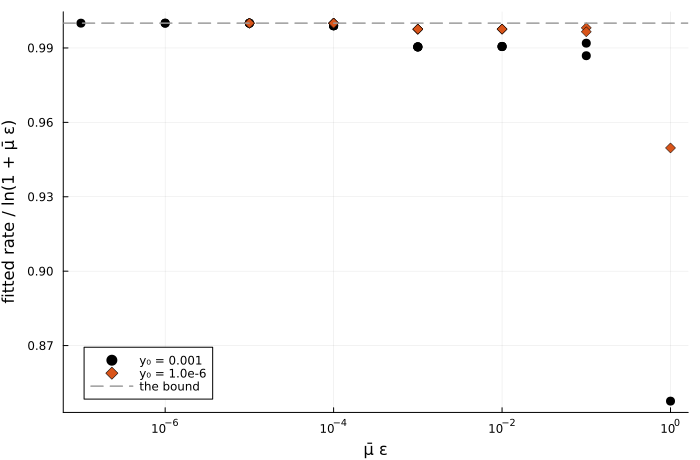

In [15]:
let plt = plot(xlabel = "μ̄ ε", ylabel = "fitted rate / ln(1 + μ̄ ε)",
               xscale = :log10, legend = :bottomleft, size = (700, 460))
    for (j, y0) in enumerate(SS_Y0)
        rs = [r for r in GAP if r.y0 == y0]
        isempty(rs) && continue
        o = sortperm([r.me for r in rs])
        scatter!(plt, [rs[i].me for i in o], [rs[i].ratio for i in o];
                 label = "y₀ = $y0", color = j == 1 ? SS_BLACK : SS_ACCENT,
                 marker = j == 1 ? :circle : :diamond, ms = 5,
                 markerstrokewidth = 0.5)
    end
    hline!(plt, [1.0]; color = SS_GREY, linestyle = :dash, lw = 1.5,
           label = "the bound")
    savefig(plt, joinpath(OUTDIR, "flat_regions_fig7_gap.pdf"))
    display(plt)
end

## 9. The tables

Read from the archive. Nothing here is recomputed except the columns marked as
derived, which are $\ln(1+\overline{\mu}\varepsilon)$, the ratio to the fitted
rate and the collapse product. `never` is a category and never a number.

In [16]:
kesc_s(k) = k === nothing ? "never" : string(k)

println("="^122)
println("TABLE 1. The (mu_bar, eps) grid, R-grad capped, rate regime, x0 = 0.")
println("Derived here: ln(1+mu*eps), the ratio, and the collapse product.")
println("="^122)
@printf("%8s %8s %8s %10s %12s %12s %9s %12s %6s %18s\n",
        "y0", "mu_bar", "eps", "k_esc", "fitted rate", "ln(1+mu*e)", "ratio",
        "mu*e*k_esc", "n", "outcome")
println("-"^122)
for y0 in SS_Y0, μ̄ in SS_MUBAR, ε in SS_EPS
    rs = sel(regime = :rate, rule = "RGradCapped", param = μ̄, ε = ε, y0 = y0, x0 = 0.0)
    isempty(rs) && continue
    r = rs[1]; b = log1p(μ̄ * ε)
    @printf("%8g %8g %8g %10s %12.6f %12.6f %9s %12s %6d %18s\n",
            y0, μ̄, ε, kesc_s(r.kesc), r.rate, b,
            (isfinite(r.rate) && b > 0) ? @sprintf("%.4f", r.rate / b) : "n/a",
            r.kesc === nothing ? "n/a" : @sprintf("%.4f", μ̄ * ε * r.kesc),
            r.rate_n, string(ss_class(r)))
end

TABLE 1. The (mu_bar, eps) grid, R-grad capped, rate regime, x0 = 0.
Derived here: ln(1+mu*eps), the ratio, and the collapse product.
      y0   mu_bar      eps      k_esc  fitted rate   ln(1+mu*e)     ratio   mu*e*k_esc      n            outcome
--------------------------------------------------------------------------------------------------------------------------
   0.001     0.01      0.1       6362     0.000990     0.001000    0.9904       6.3620   6362               slow
   0.001     0.01     0.01      never     0.000100     0.000100    0.9989          n/a  50001              never
   0.001     0.01    0.001      never     0.000010     0.000010    1.0000          n/a  50001              never
   0.001     0.01   0.0001      never     0.000001     0.000001    1.0000          n/a  50001              never
   0.001     0.01    1e-05      never     0.000000     0.000000    1.0000          n/a  50001              never
   0.001      0.1      0.1        639     0.009857     0.009950  

In [17]:
println("\n", "="^116)
println("TABLE 2. The zeta grid, R-DFO started inside the band, rate regime.")
println("k0 is computed in Section 4 from the trace; the archive carries the outcome.")
println("="^116)
@printf("%8s %8s %8s %10s %12s %12s %9s %12s %18s\n",
        "y0", "zeta", "eps", "k_esc", "fitted rate", "ln(1+g3*z*e)", "ratio",
        "g3*z*e*kesc", "outcome")
println("-"^116)
for y0 in SS_Y0, ζ in SS_ZETA, ε in SS_EPS
    rs = sel(regime = :dfo_entry, rule = "RDFO", param = ζ, ε = ε, y0 = y0, x0 = 0.0)
    isempty(rs) && continue
    r = rs[1]; C = G3 * ζ; b = log1p(C * ε)
    @printf("%8g %8g %8g %10s %12.6f %12.6f %9s %12s %18s\n",
            y0, ζ, ε, kesc_s(r.kesc), r.rate, b,
            (isfinite(r.rate) && b > 0) ? @sprintf("%.4f", r.rate / b) : "n/a",
            r.kesc === nothing ? "n/a" : @sprintf("%.4f", C * ε * r.kesc),
            string(ss_class(r)))
end
println()
println("Rows with k_esc = never are rows, not omissions. gamma3 = ", G3, ".")


TABLE 2. The zeta grid, R-DFO started inside the band, rate regime.
k0 is computed in Section 4 from the trace; the archive carries the outcome.
      y0     zeta      eps      k_esc  fitted rate ln(1+g3*z*e)     ratio  g3*z*e*kesc            outcome
--------------------------------------------------------------------------------------------------------------------
   0.001     0.01      0.1       6048     0.001030     0.001998    0.5154      12.0960               slow
   0.001     0.01     0.01      never     0.000104     0.000200    0.5189          n/a              never
   0.001     0.01    0.001      never     0.000011     0.000020    0.5538          n/a              never
   0.001     0.01   0.0001      never     0.000001     0.000002    0.7231          n/a              never
   0.001     0.01    1e-05      never     0.000000     0.000000    0.7472          n/a              never
   0.001      0.1      0.1        610     0.010203     0.019803    0.5152      12.2000               

In [18]:
println("\n", "="^96)
println("TABLE 3. The two measures. Fitted ratio, predicted ratio of Section 7,")
println("and their difference, one row per (y0, mu_bar, eps) that escaped in both.")
println("="^96)
@printf("%8s %8s %8s %10s %10s %10s %12s %12s\n",
        "y0", "mu_bar", "eps", "k(|g|)", "k(tau)", "fitted", "predicted", "difference")
println("-"^96)
for r in RATIOS
    @printf("%8g %8g %8g %10d %10d %10.4f %12.4f %12.4f\n",
            r.y0, r.μ̄, r.ε, r.ka, r.kb, r.fitted, r.pred, r.diff)
end


TABLE 3. The two measures. Fitted ratio, predicted ratio of Section 7,
and their difference, one row per (y0, mu_bar, eps) that escaped in both.
      y0   mu_bar      eps     k(|g|)     k(tau)     fitted    predicted   difference
------------------------------------------------------------------------------------------------
   0.001     0.01      0.1       6362        736     8.6440       8.6341       0.0100
   0.001      0.1      0.1        639         74     8.6351       8.6341       0.0011
   0.001      0.1     0.01       6362        736     8.6440       8.6341       0.0100
   0.001        1      0.1         67          7     9.5714       8.6341       0.9374
   0.001        1     0.01        639         74     8.6351       8.6341       0.0011
   0.001        1    0.001       6362        736     8.6440       8.6341       0.0100
   0.001       10      0.1         12          3     4.0000       8.6341      -4.6341
   0.001       10     0.01         69         10     6.9000       8.6

## 10. Findings

The report already carries a findings section for `Survey-part3-v1.tex`. We do
not repeat it and we do not apply it. What follows is only what this notebook's
own figures and integrals reveal, with the source string and the line it was read
at.

**One finding. Line 1150, the constant of the capped escape time.** The source
reads

```
    t_{\mathrm{esc}} \;\approx\; \frac{\ln(1/\abs{y_0})}{\overline{\mu}\,\varepsilon} ,
```

carrying `\label{eqn: escape time capped}` at line 1151. The collapse product is
computed below cell by cell and compared with three candidate constants at four
thresholds on $\overline{\mu}\varepsilon$. The threshold matters and is not a
convenience: the continuous limit replaces $\ln(1+\overline{\mu}\varepsilon)$ by
$\overline{\mu}\varepsilon$, which fails at the one cell where that product is $1$. The
report makes the same restriction in its own finding, keeping the rows with
$\varepsilon \leq 10^{-3}$. Over the cells where the limit applies, the residual for
$\ln(1/\abs{y_0})$ is two orders of magnitude larger than for
$\ln(1/(\sqrt3\abs{y_0}))$, for the reason `eqn: exact constant` of the report
gives. The factor $\sqrt3$ comes from $1-y^2$ at the escape threshold.

This is not the finding the report makes at line 1107. That one is about the
caption of `tab: slow saddle`, which reports the model axis under $\Rdelta$. Line
1150 sits in the radius-axis paragraph and is the equation the collapse test of
line 1157 is stated against, so it is what this notebook measures. The same
constant stands at line 1081 in `eqn: escape time`, where the source says
`linearises to`, so it is stated there as an approximation and the case is
weaker.

We describe and do not apply. Both readings stand: the source may keep
$\ln(1/\abs{y_0})$ as the leading behaviour of the linearised flow, or take
$\ln(1/(\sqrt3\abs{y_0}))$ as the constant the collapse actually lands on. The
author chooses.

**Nothing else is new.** The envelope, the binding radius and the two tolerance
regimes all confirm statements the report already makes, and the corrected $\tau$
constant of Section 7 and the unoccupied second branch of `prop: rdfo` in
Section 4 are findings about the report rather than about the subsection.

In [19]:
println("="^104)
println("The collapse product mu_bar*eps*k_esc, cell by cell.")
println("The continuous limit needs mu_bar*eps small, so the product is listed with it.")
println("="^104)
@printf("%8s %8s %8s %10s %12s %14s\n",
        "y0", "mu_bar", "eps", "k_esc", "mu*eps", "mu*eps*k_esc")
println("-"^104)
COLLAPSE = NamedTuple[]
for y0 in SS_Y0, μ̄ in SS_MUBAR, ε in SS_EPS
    rs = sel(regime = :rate, rule = "RGradCapped", param = μ̄, ε = ε, y0 = y0, x0 = 0.0)
    (isempty(rs) || rs[1].kesc === nothing) && continue
    p = μ̄ * ε * rs[1].kesc
    push!(COLLAPSE, (y0 = y0, μ̄ = μ̄, ε = ε, me = μ̄ * ε, kesc = rs[1].kesc, prod = p))
    @printf("%8g %8g %8g %10d %12.3g %14.4f\n", y0, μ̄, ε, rs[1].kesc, μ̄ * ε, p)
end

println()
println("="^104)
println("Residuals of the mean product against the three candidate constants,")
println("at four thresholds on mu_bar*eps. Line 1150 of Survey-part3-v1.tex")
println("carries ln(1/|y0|); eqn: exact constant of the report gives ln(1/(sqrt3 y0)).")
println("="^104)
@printf("%8s %12s %7s %12s %12s %12s %12s\n",
        "y0", "mu*eps <=", "cells", "mean prod", "|- ln(1/y0)|",
        "|- ln(1/2y0)|", "|- ln(1/r3y0)|")
println("-"^104)
for y0 in SS_Y0, cut in (1.0, 1e-1, 1e-2, 1e-3)
    ps = [c.prod for c in COLLAPSE if c.y0 == y0 && c.me <= cut * (1 + 1e-9)]
    isempty(ps) && continue
    m = sum(ps) / length(ps)
    c1, c2, c3 = log(1 / y0), log(1 / (2y0)), log(1 / (sqrt(3) * y0))
    @printf("%8g %12g %7d %12.4f %12.4f %12.4f %12.4f\n",
            y0, cut, length(ps), m, abs(m - c1), abs(m - c2), abs(m - c3))
end

println()
println("The row at mu*eps <= 1 includes the cell where mu_bar*eps = 1, at which")
println("ln(1 + mu_bar*eps) is not mu_bar*eps and the continuous limit does not")
println("apply. The report makes the same restriction in its own finding, keeping")
println("the rows with eps <= 1e-3.")
println()
println("The sqrt(3) constant is also the I_grad of Section 7, computed there by")
println("quadrature and checked against the closed form to 1e-13.")

The collapse product mu_bar*eps*k_esc, cell by cell.
The continuous limit needs mu_bar*eps small, so the product is listed with it.
      y0   mu_bar      eps      k_esc       mu*eps   mu*eps*k_esc
--------------------------------------------------------------------------------------------------------
   0.001     0.01      0.1       6362        0.001         6.3620
   0.001      0.1      0.1        639         0.01         6.3900
   0.001      0.1     0.01       6362        0.001         6.3620
   0.001        1      0.1         67          0.1         6.7000
   0.001        1     0.01        639         0.01         6.3900
   0.001        1    0.001       6362        0.001         6.3620
   0.001       10      0.1         12            1        12.0000
   0.001       10     0.01         69          0.1         6.9000
   0.001       10    0.001        642         0.01         6.4200
   0.001       10   0.0001       6364        0.001         6.3640
   1e-06     0.01      0.1      13273

In [20]:
println("="^88)
println("Closing summary")
println("="^88)
@printf("archive read                         : %s\n", basename(ARCH))
@printf("runs rerun for the figures           : paths %d, envelope %d, binding 1, ",
        length(SS_X0) * 3, length(ENVROWS))
@printf("dfo %d, measures %d\n", length(DFO) + length(DFO_SCAN), length(MEAS))
println()
@printf("any run crossing the envelope        : %s\n",
        any(r.crossed for r in ENVROWS) ? "YES" : "no")
@printf("worst |y|/envelope over those runs   : %.6f\n", maximum(r.worst for r in ENVROWS))
println()
for I in INTEG
    @printf("y0 = %-8g I_grad %.6f  I_tau %.6f  predicted ratio %.4f\n",
            I.y0, I.I_grad, I.I_tau, I.ratio)
end
for y0 in SS_Y0
    rs = [r for r in RATIOS if r.y0 == y0 && r.kb >= 20]
    isempty(rs) && continue
    @printf("y0 = %-8g fitted %.4f to %.4f against predicted %.4f, worst error %.2f%% (k(tau) >= 20)\n",
            y0, minimum(r.fitted for r in rs), maximum(r.fitted for r in rs),
            rs[1].pred, 100 * maximum(abs(r.rel) for r in rs))
end
for y0 in SS_Y0
    rs = [r for r in RATIOS if r.y0 == y0]
    isempty(rs) && continue
    @printf("y0 = %-8g fitted %.4f to %.4f against predicted %.4f, worst error %.2f%% (every cell)\n",
            y0, minimum(r.fitted for r in rs), maximum(r.fitted for r in rs),
            rs[1].pred, 100 * maximum(abs(r.rel) for r in rs))
end
println()
let rs = [r for r in GAP if r.me <= 1e-1]
    @printf("gap for mu_bar*eps <= 0.1            : %d cells, ratio %.4f to %.4f\n",
            length(rs), minimum(r.ratio for r in rs), maximum(r.ratio for r in rs))
end
let rs = [r for r in GAP if r.me > 1e-1]
    isempty(rs) || @printf("gap for mu_bar*eps > 0.1             : %d cells, ratio %.4f to %.4f\n",
                           length(rs), minimum(r.ratio for r in rs),
                           maximum(r.ratio for r in rs))
end
@printf("zeta cells that never entered the band: %d of %d\n",
        count(r -> r.k0 === nothing, DFO_SCAN), length(DFO_SCAN))
println()
println("Figures written to ", OUTDIR)
for f in ("flat_regions_fig1_paths.pdf", "flat_regions_fig2_envelope.pdf",
          "flat_regions_fig3_binding.pdf", "flat_regions_fig4_dfo_entry.pdf",
          "flat_regions_fig5_measures.pdf", "flat_regions_fig6_outcomes.pdf",
          "flat_regions_fig7_gap.pdf")
    @printf("   %-40s %s\n", f, isfile(joinpath(OUTDIR, f)) ? "ok" : "MISSING")
end
println("\nDONE.")

Closing summary
archive read                         : exp_2026-08-29_21-51-19_slow_saddle
runs rerun for the figures           : paths 6, envelope 3, binding 1, dfo 14, measures 2

any run crossing the envelope        : no
worst |y|/envelope over those runs   : 1.000000

y0 = 0.001    I_grad 6.358449  I_tau 0.736439  predicted ratio 8.6341
y0 = 1e-06    I_grad 13.266204  I_tau 0.737438  predicted ratio 17.9896
y0 = 0.001    fitted 8.4474 to 8.6440 against predicted 8.6341, worst error 2.16% (k(tau) >= 20)
y0 = 1e-06    fitted 17.5789 to 18.0270 against predicted 17.9896, worst error 2.28% (k(tau) >= 20)
y0 = 0.001    fitted 4.0000 to 9.5714 against predicted 8.6341, worst error 53.67% (every cell)
y0 = 1e-06    fitted 7.3333 to 19.8571 against predicted 17.9896, worst error 59.24% (every cell)

gap for mu_bar*eps <= 0.1            : 35 cells, ratio 0.9869 to 1.0000
gap for mu_bar*eps > 0.1             : 2 cells, ratio 0.8476 to 0.9497
zeta cells that never entered the band: 3 of 12

F